<html><div style="font-size:7pt">This notebook may contain text, code and images generated by artificial intelligence. Used model: claude-sonnet-4-6, vision model: claude-sonnet-4-6, fast_model: None, endpoint: None, bia-bob version: 0.35.0.. It is good scientific practice to check the code and results it produces carefully. <a href="https://github.com/haesleinhuepf/bia-bob">Read more about code generation using bia-bob</a></div></html>

# Blob Segmentation and Analysis

This notebook performs the following steps:
1. Load the image `blobs.tif`
2. Segment the bright objects using thresholding and connected component labeling
3. Measure the area and perimeter of each segmented object
4. Plot the area against the perimeter to visualize the relationship

## Import Libraries

We start by importing all required libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import stackview
from skimage.io import imread
from skimage.measure import regionprops_table
import pyclesperanto as cle

## Step 1: Load the Image

We load the `blobs.tif` image from disk and display it to get an overview of the data.

Image shape: (254, 256)
Image dtype: uint8


[[ 40  32  24 ... 216 200 200]
 [ 56  40  24 ... 232 216 216]
 [ 64  48  24 ... 240 232 232]
 ...
 [ 72  80  80 ...  48  48  48]
 [ 80  80  80 ...  48  48  48]
 [ 96  88  80 ...  48  48  48]]
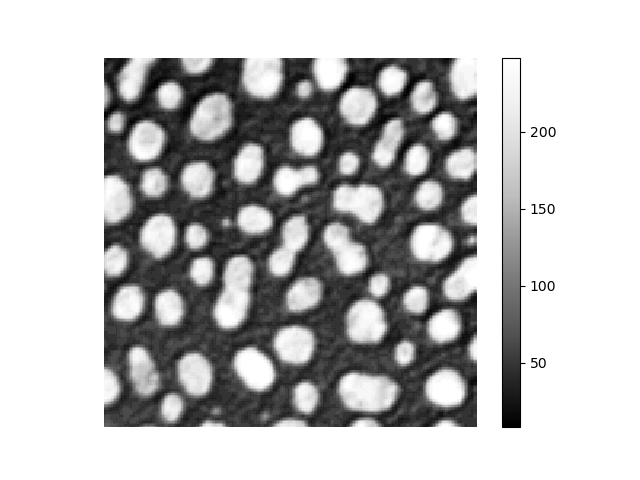
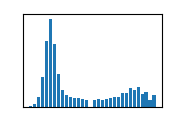

In [2]:
image = imread("blobs.tif")

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
stackview.insight(image)

## Step 2: Segment the Bright Objects

We use Otsu thresholding to create a binary image separating bright objects from the background, followed by connected component labeling to assign unique IDs to each object.

[[0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
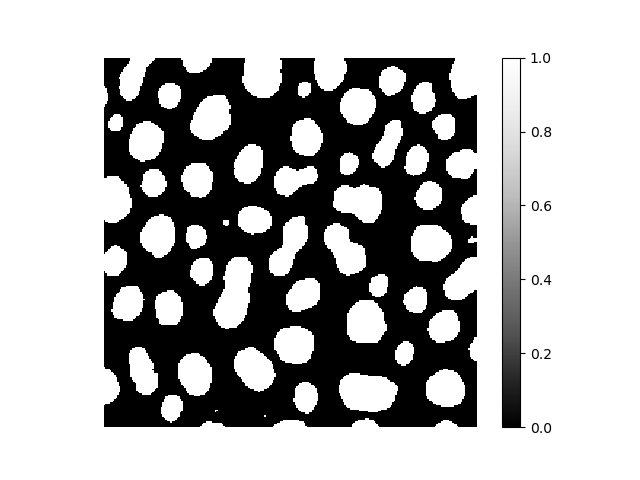
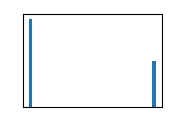

In [3]:
binary_image = cle.threshold_otsu(image)

stackview.insight(binary_image)

## Step 3: Label the Segmented Objects

We apply connected component labeling to the binary image to assign a unique integer label to each distinct object.

Number of objects detected: 64


[[0 0 0 ... 5 5 5]
 [0 0 0 ... 5 5 5]
 [0 0 0 ... 5 5 5]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
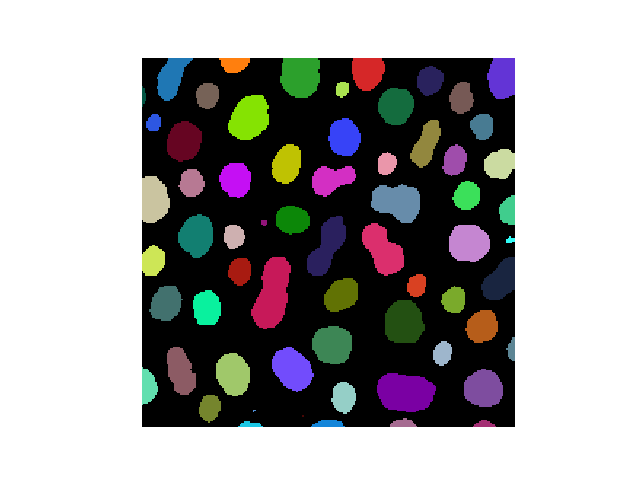

In [4]:
label_image = cle.connected_component_labeling(binary_image)

print("Number of objects detected:", int(label_image.max()))
stackview.insight(label_image)

## Step 4: Measure Area and Perimeter

Using `skimage.measure.regionprops_table`, we measure the area and perimeter of each labeled object and store the results in a Pandas DataFrame.

In [5]:
properties = ['label', 'area', 'perimeter']
measurements = regionprops_table(
    np.asarray(label_image).astype(int),
    properties=properties
)
df = pd.DataFrame(measurements)

display(df.head())

,label,area,perimeter
0,1,433.0,91.254834
1,2,185.0,53.556349
2,3,658.0,95.698485
3,4,434.0,76.870058
4,5,477.0,83.798990


## Step 5: Plot Area vs. Perimeter

We create a scatter plot to visualize the relationship between the area and perimeter of the segmented objects.

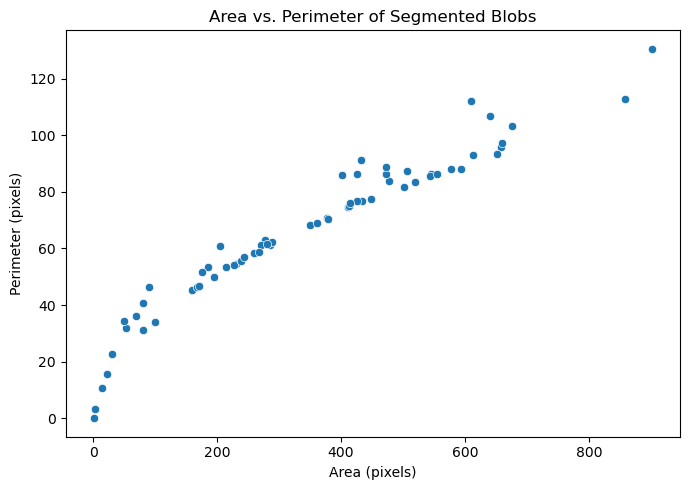

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x='area', y='perimeter', ax=ax)
ax.set_title('Area vs. Perimeter of Segmented Blobs')
ax.set_xlabel('Area (pixels)')
ax.set_ylabel('Perimeter (pixels)')
plt.tight_layout()
plt.show()